Script for plotting evolution of system indicators for single replication of the experiment

In [ ]:
### INPUT ###
repl_id = 0
scenario_name = 'sp-repl_id-{}'.format(repl_id)
dem_mgmt_schemes = ['tmc100', 'tmc20', 'tmc15', 'tmc10', 'tmc5', 'tmc3', 'tmc1']
# dem_mgmt_schemes = ['tmc10']
dem_mgmt_labels = ['TMC100', 'TMC20', 'TMC15', 'TMC10', 'TMC5', 'TMC3', 'TMC1']
# dem_mgmt_labels = ['TMC10']
mode_labels = ["Car", "RH - solo", "RH - pool", "PT", "Bike"]

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from eval_utils import *
import matplotlib.ticker as mtick
import numpy as np

In [ ]:
## Initialise evaluation ##

# Set paths
path = os.getcwd()
result_path = os.path.join(path,'..','..','..','results')
if not os.path.exists(os.path.join(path, 'plots', str(repl_id))):
    os.mkdir(os.path.join(path, 'plots', str(repl_id)))

# Initialise dictionaries that will contain different demand management schemes
params = {}
evo_df = {}

In [4]:
# Load different demand management schemes
for scheme in dem_mgmt_schemes:
    # Result path for demand management scenario
    scheme_path = os.path.join(result_path, '{}-{}'.format(scheme, scenario_name))
    if os.path.exists(scheme_path):
        # Load params
        with open(os.path.join(scheme_path,'0_params.json')) as f:
            params[scheme] = json.load(f)
        # Load relevant csv's: market shares and credit market indicators
        market_shares = load_market_indicators(scheme_path)
        market_shares.index.name = 'day'
        evo_df[scheme] = market_shares.copy().drop(['ptcp_dem_mh','ptcp_sup_mh','ptcp_sup_sh_0','ptcp_sup_sh_1'], axis=1)
        # evo_df[scheme] = market_shares[['ptcp_dem_sh_0','ptcp_dem_sh_1','bike','car','pt']].copy()
        evo_df[scheme] = evo_df[scheme].rename(columns={'ptcp_dem_sh_0': 'rh_solo', 'ptcp_dem_sh_1': 'rh_pool', 'paxkm_rs_0': 'paxkm_solo', 'paxkm_rs_1': 'paxkm_pool', 'vkt_rs_0': 'vkt_solo', 'vkt_rs_1': 'vkt_pool'})
        if scheme.startswith('tmc'):
            evo_df[scheme]['not_enough_credit'] = market_shares['not_enough_credit']
            tmc_indicators = load_tmc_indicators(scheme_path)
            tmc_indicators.index.name = 'mc_iter'
            evo_df[scheme] = pd.concat([evo_df[scheme], tmc_indicators], axis=1)
            # evo_df[scheme] = evo_df[scheme].loc[evo_df[scheme].index >= (params[scheme]['nD'] - params[scheme]['tmc']['duration'])]
            evo_df[scheme].reset_index(drop=True, inplace=True)
            evo_df[scheme].index.name = 'mc_iter'
n_days_eql = params[scheme]['convergence']['moving_average_window']+params[scheme]['convergence']['stable_iters']

In [5]:
evo_df['tmc10']

,rh_solo,rh_pool,bike,car,pt,not_enough_credit,paxkm_bike,trips_bike_center,paxkm_car,trips_car_center,...,trips_pt_center,paxkm_solo,trips_rs_0_center,paxkm_pool,trips_rs_1_center,total_perc_gtt,i_mode_choice,price,transaction_volume,oversupply
mc_iter,,,,,,,,,,,,,,,,,,,,,
0,11,108,1332,303,69,0,6452.947761,0,1382.347158,0,...,0,36.870038,0,500.521387,0,1049.698430,0,0.156,11494.598351,-4.248286
1,9,116,1320,307,71,0,6388.033848,0,1421.150689,0,...,0,21.781698,0,527.979519,0,1041.042138,1,0.158,11494.213494,8.689893
2,12,108,1320,308,75,0,6370.911322,0,1420.924447,0,...,0,36.462215,0,508.466835,0,1040.220912,2,0.159,11472.638640,-20.610782
3,10,122,1322,300,69,0,6436.485227,0,1350.018381,0,...,0,33.173592,0,541.446564,0,1043.388715,3,0.159,11470.728393,-24.885635
4,13,112,1322,300,76,0,6387.306782,0,1369.621837,0,...,0,29.036373,0,523.905056,0,1045.858242,4,0.159,11472.577576,-20.569162
5,11,109,1328,304,71,0,6421.225072,0,1400.413767,0,...,0,47.813607,0,505.109362,0,1040.395685,5,0.159,11472.520000,-20.792176
6,11,114,1329,306,63,0,6440.298295,0,1382.352903,0,...,0,35.430299,0,547.691973,0,1037.025751,6,0.159,11473.450481,-18.451263


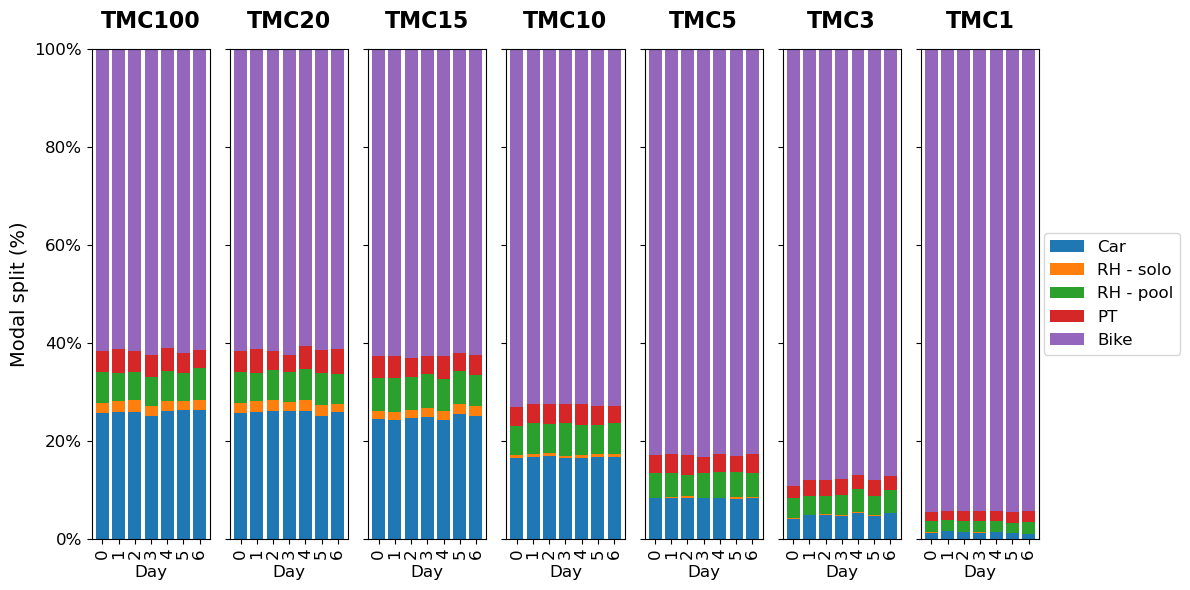

In [6]:
### Plot TMC scenario evolution
n_tmc_scenarios = sum(1 for item in dem_mgmt_schemes if item.startswith("tmc"))
# height_ratios = [2, 1, 1, 1]
fig, axes = plt.subplots(nrows=1, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0

for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"): 
        # Plot 1: market shares
        evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].div(params[scheme]['nP']).mul(100).plot(kind='bar', stacked=True, ax=axes[i], width=0.8)
        axes[i].set_ylabel('Modal split (%)',fontsize=14)
        axes[i].get_legend().remove()
        # axes[i].set_xticks(range(0, params[scheme]['tmc']['duration'], 5))
        # axes[i].set_xticklabels(range(0, params[scheme]['tmc']['duration'], 5),rotation=0)
        axes[i].set_xlabel('Day', fontsize=12)
        axes[i].set_ylim(0,100)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

        # # Plot 4: mean_balance
        # plot_index = 3
        # evo_df[scheme]['mean_balance'].plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Avg. credit balance', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # # Plot 2: credit_price
        # plot_index = 1
        # evo_df[scheme]['price'].plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Credit price (€)', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # # Plot 3: transaction volume
        # plot_index = 2
        # (evo_df[scheme]['transaction_volume'] / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        # ((abs(evo_df[scheme]['oversupply'])) / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Avg. buy/sell offer quant.', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Subtitle for scheme
        axes[i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=15, fontsize=16)

        if i == n_tmc_scenarios-1:
            axes[i].legend(labels=mode_labels, bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)
            # axes[2, i].legend(labels=['Successful', 'Denied'], bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)

        i+=1

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'tmc-evo-modalsplit.png'), facecolor='w')


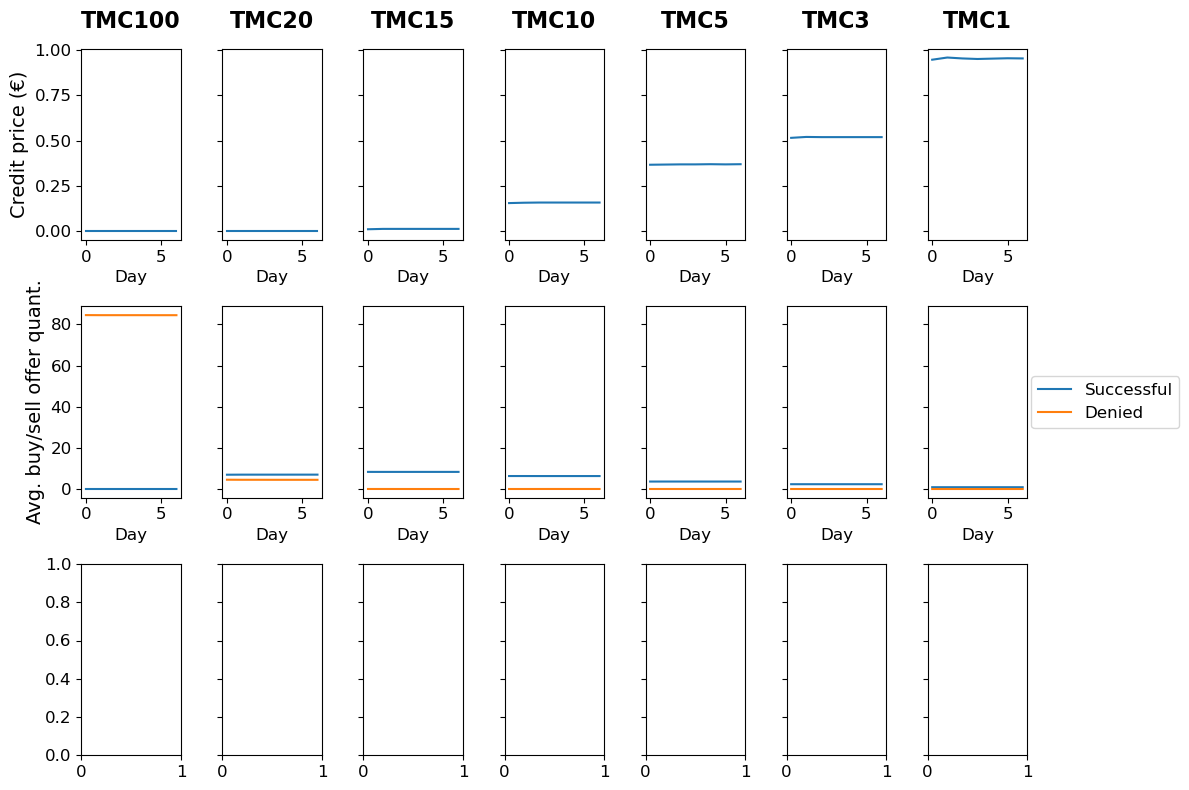

In [7]:
### Plot TMC scenario evolution
n_tmc_scenarios = sum(1 for item in dem_mgmt_schemes if item.startswith("tmc"))
height_ratios = [1, 1, 1]
fig, axes = plt.subplots(nrows=3, ncols=n_tmc_scenarios, figsize=(12, 8), sharey='row', gridspec_kw={'height_ratios': height_ratios})
i = 0

for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"): 
        # Plot 1: market shares
        # evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].div(params[scheme]['nP']).mul(100).plot(kind='bar', stacked=True, ax=axes[0, i], width=0.8)
        # axes[0, i].set_ylabel('Modal split (%)',fontsize=14)
        # axes[0, i].get_legend().remove()
        # axes[0, i].set_xticks(range(0, params[scheme]['tmc']['duration'], 5))
        # axes[0, i].set_xticklabels(range(0, params[scheme]['tmc']['duration'], 5),rotation=0)
        # axes[0, i].set_xlabel('Day', fontsize=12)
        # axes[0, i].set_ylim(0,100)
        # axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())

        # Plot 4: mean_balance
        # plot_index = 2
        # evo_df[scheme]['mean_balance'].plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Avg. credit balance', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Plot 2: credit_price
        plot_index = 0
        evo_df[scheme]['price'].plot(ax=axes[plot_index, i])
        axes[plot_index, i].set_ylabel('Credit price (€)', fontsize=14)
        axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Plot 3: transaction volume
        plot_index = 1
        (evo_df[scheme]['transaction_volume'] / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        ((abs(evo_df[scheme]['oversupply'])) / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        axes[plot_index, i].set_ylabel('Avg. buy/sell offer quant.', fontsize=14)
        axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=15, fontsize=16)

        if i == n_tmc_scenarios-1:
            # axes[0, i].legend(labels=mode_labels, bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)
            axes[1, i].legend(labels=['Successful', 'Denied'], bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)

        i+=1

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'tmc-evo-trading.png'), facecolor='w')


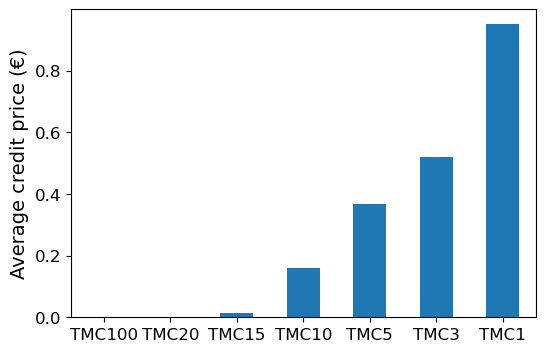

In [8]:
price_dict = dict()
tmc_labels = []
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        tmc_labels.append(scheme.replace("tmc", "TMC"))
        price_dict[scheme] = evo_df[scheme].price.mean() 

price_dict = {k:[v] for k,v in price_dict.items()}
ax = pd.DataFrame(price_dict).T.plot(kind='bar', figsize=(6, 4), legend=False)
ax.set_xticklabels(tmc_labels, rotation=0, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
# Adding labels and title to the plot
# plt.xlabel('TMC Scenarios')
plt.ylabel('Average credit price (€)', fontsize=14)
# plt.title('Average Credit Price for TMC Scenarios')

plt.savefig(os.path.join(path, 'plots', str(repl_id),'avg_credit_price.png'), facecolor='w')
# Displaying the plot
plt.show()

In [9]:
evo_df['tmc10'].price
pd.DataFrame(price_dict)

,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3,tmc1
0,0.0,0.0,0.013714,0.158429,0.368857,0.518571,0.951286


,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3,tmc1
car,25.914897,25.891388,24.794295,16.675809,8.330068,4.850717,1.363530
rh_solo,2.092313,2.006112,1.771021,0.603401,0.180237,0.148891,0.039182
rh_pool,6.057519,6.206410,6.715775,6.182901,5.015281,4.153280,2.288222
pt,4.333516,4.451062,4.121934,3.871170,3.589060,3.032678,2.013949
bike,61.601755,61.445028,62.596975,72.666719,82.885354,87.814435,94.295118
not_enough_credit,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


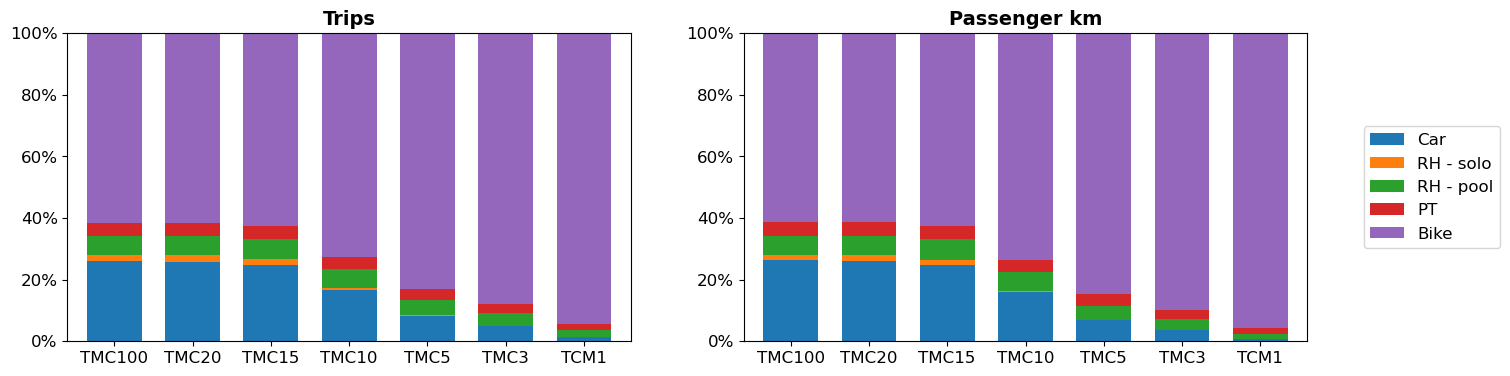

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

### Determine average indicators for TMC scenario - market share in trips
modal_split_trips = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    # if not scheme.startswith('tmc'):
    modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum(axis=0).div(evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().sum()).mul(100)
    # else:
    #     modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_dayssum().div(n_days_eql).mul(100)
modal_split_trips.T.plot.bar(stacked=True, rot=0, ax=axes[0], width=0.7)
axes[0].get_legend().remove()
axes[0].set_xticklabels(dem_mgmt_labels)
axes[0].set_title('Trips', fontweight='bold', fontsize=14)
axes[0].set_ylim(0,100)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
modal_split_trips

### Determine average indicators for TMC scenario - market share in pax km
modal_split_paxkm = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    df = evo_df[scheme][['paxkm_car','paxkm_solo','paxkm_pool','paxkm_pt', 'paxkm_bike']]
    # if not scheme.startswith('tmc'):
    modal_split_paxkm[scheme] = df.tail(n_days_eql).sum(axis=0).div(df.tail(n_days_eql).sum().sum()).mul(100)
    # else:
        # modal_split_paxkm[scheme] = df.sum(axis=0).div(df.sum().sum()).mul(100)
modal_split_paxkm.T.plot.bar(stacked=True, ax=axes[1], width=0.7, rot=0)
axes[1].set_xticklabels(dem_mgmt_labels, fontsize=12)
axes[1].legend(labels=mode_labels, bbox_to_anchor=(1.1, 0.5), loc="center left", borderaxespad=0, fontsize=12)
axes[1].set_title('Passenger km', fontweight='bold', fontsize = 14)
axes[1].set_ylim(0,100)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
modal_split_paxkm

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.6 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in axes[0].containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])
for container in axes[1].containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

plt.savefig(os.path.join(path, 'plots', str(repl_id),'market-shares.png'), facecolor='w')

modal_split_trips

In [17]:
evo_df['tmc10'][['paxkm_car','paxkm_solo','paxkm_pool','paxkm_pt', 'paxkm_bike']].tail(n_days_eql).sum().div(n_days_eql)

paxkm_car     1215.853648
paxkm_solo      30.070978
paxkm_pool     456.890087
paxkm_pt       304.242880
paxkm_bike    5612.151038
dtype: float64

,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3,tmc1
car,22.675535,22.654964,21.695008,14.591333,7.288810,4.244377,1.193088
rh_solo,1.830773,1.755348,1.549643,0.527976,0.157707,0.130280,0.034284
rh_pool,5.300329,5.430609,5.876303,5.410038,4.388371,3.634120,2.002194
pt,3.791827,3.894679,3.606692,3.387274,3.140428,2.653593,1.762205
bike,53.901536,53.764399,54.772353,63.583379,72.524685,76.837630,82.508228
not_enough_credit,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


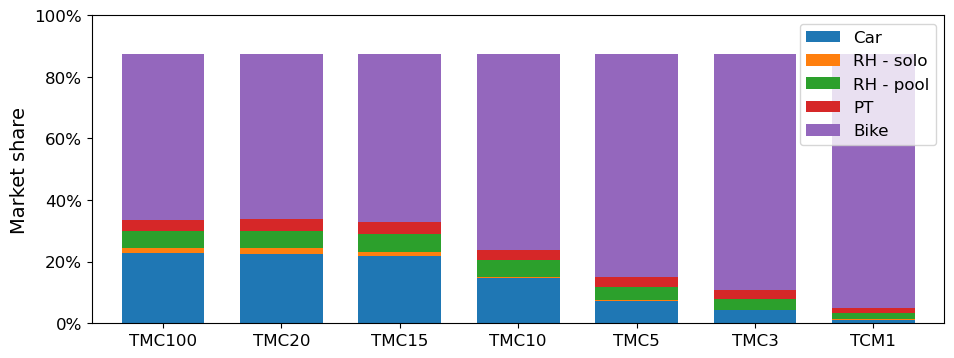

In [19]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

### Determine average indicators for TMC scenario - market share in trips
modal_split_trips = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    # if not scheme.startswith('tmc'):
    modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().div(params[scheme]['nP']*n_days_eql).mul(100)
    # else:
    # modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].sum().div(params[scheme]['nP']*params[scheme]['tmc']['duration']).mul(100)
ax = modal_split_trips.T.plot.bar(stacked=True, rot=0, width=0.7, figsize=(11,4))
ax.get_legend().remove()
ax.set_xticklabels(dem_mgmt_labels)
ax.set_ylim(0,100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(mode_labels, fontsize=12)
modal_split_trips

ax.set_ylabel('Market share', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.6 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

plt.savefig(os.path.join(path, 'plots', str(repl_id),'market-shares_trips_only.png'), facecolor='w')

modal_split_trips

In [20]:
# ## Market share in trips for which the shortest path by car traverses the city centre
# modal_split_trips_center = pd.DataFrame()
# for scheme in dem_mgmt_schemes:
#     if not scheme.startswith('tmc'):
#         modal_split_trips_center[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().div(params[scheme]['nP']*n_days_eql).mul(100)
#     else:
#         modal_split_trips_center[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].sum().div(params[scheme]['nP']*params[scheme]['tmc']['duration']).mul(100)
# ax = modal_split_trips_center.T.plot.bar(stacked=True, rot=0, width=0.7)
# ax.get_legend().remove()
# ax.set_xticklabels(dem_mgmt_labels)
# ax.set_title('Trips', fontweight='bold', fontsize=14)
# ax.set_ylim(0,100)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
# modal_split_trips

In [21]:
fig = plt.figure(figsize=(30, 6))

# Vehicle kilometres
vkt = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    if not scheme.startswith('tmc'):
        vkt[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].tail(n_days_eql).mean()
    else:
        vkt[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].mean()
ax = (vkt / 1000).T.plot.bar(stacked=True, rot=0, width=0.7, figsize=(11, 4))
ax.set_xticklabels(dem_mgmt_labels, fontsize=12)
ax.set_ylabel('Vehicle km (x1000)', fontsize=14)
ax.legend(labels=['Car', 'RH - solo', 'RH - pool'], fontsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.5 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'vkt.png'), facecolor='w')
(vkt / vkt['None'].sum()).sum(axis=0)

KeyError: "None of [Index(['vkt_car', 'vkt_solo', 'vkt_pool'], dtype='object')] are in the [columns]"

<Figure size 3000x600 with 0 Axes>

None          1.000000
cgp10         0.865047
cgp20         0.817962
city_cgp10    0.563380
city_cgp20    0.421846
lpr           0.715169
tmc50         0.902383
tmc25         0.779645
tmc15         0.583314
tmc10         0.387082
tmc5          0.149646
dtype: float64

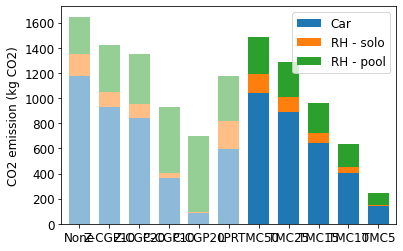

In [ ]:
# CO2 emissions
co2 = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    if not scheme.startswith('tmc'):
        co2[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].tail(n_days_eql).mean() * 0.1 * 1000 # kg CO2
        # co2[scheme]['pt'] = evo_df[scheme]['paxkm_pt'].tail(n_days_eql).mean() * 0.04 # kg CO2
        co2[scheme]['alpha'] = 1
    else:
        co2[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].mean() * 0.1 * 1000 # kg CO2
        # co2[scheme] = evo_df[scheme][['paxkm_pt']].mean() * 0.04 # kg CO2
        co2[scheme]['alpha'] = 0.5
ax = (co2 / 1000).T.plot.bar(stacked=True, rot=0, width=0.7)
ax.set_xticklabels(dem_mgmt_labels, fontsize=12)
ax.set_ylabel('CO2 emission (kg CO2)', fontsize=12)
ax.legend(labels=['Car', 'RH - solo', 'RH - pool'], fontsize=12)

# col_names = co2.columns.values.tolist()
alpha_array = np.array([1.0 if name.startswith('tmc') else 0.5 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])
# # Apply transparency conditionally
# for bar, alpha in zip(ax.patches, alpha_array):
#     print(bar, alpha)
#     bar.set_alpha(alpha)


ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'co2.png'), facecolor='w')
(co2 / co2['None'].sum()).sum(axis=0)

In [ ]:
co2

,None,cgp10,cgp20,city_cgp10,city_cgp20,lpr,tmc50,tmc25,tmc15,tmc10,tmc5
vkt_car,1.172220e+06,924963.846480,843525.439810,361190.52932,83055.569950,595918.60899,1.043150e+06,886233.353337,640494.978773,406320.176910,141201.313330
vkt_solo,1.773444e+05,124973.459120,107731.577820,41367.30800,11536.119720,218398.27881,1.512153e+05,123558.764557,78146.955927,44046.544427,10895.279797
vkt_pool,2.974263e+05,374786.659745,395918.160209,525324.02752,600184.694986,363559.13664,2.918510e+05,274276.572606,242070.494898,187153.894934,94369.203017


,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3,tmc1
total_perc_gtt,1.0,1.0,1.0,1.0,1.0,1.0,1.0


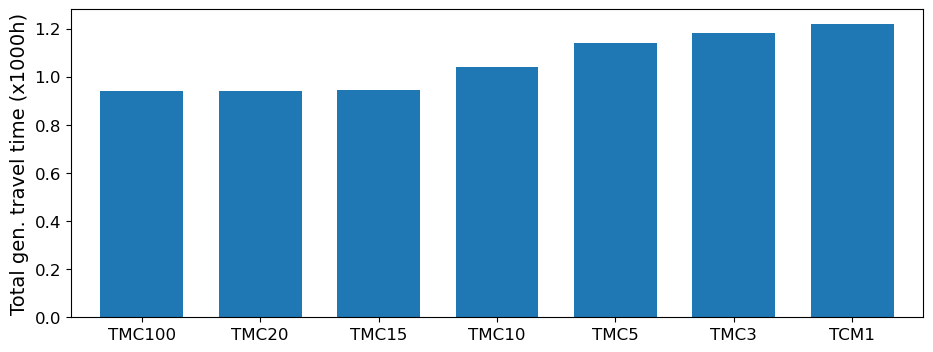

In [23]:
# Perceived gtt
perc_gtt = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    if not scheme.startswith('tmc'):
        perc_gtt[scheme] = evo_df[scheme][['total_perc_gtt']].tail(n_days_eql).mean()
    else:
        perc_gtt[scheme] = evo_df[scheme][['total_perc_gtt']].mean()
ax = (perc_gtt / 1000).T.plot.bar(rot=0, width=0.7, figsize=(11,4))
ax.set_xticklabels(dem_mgmt_labels, fontsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.5 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

ax.get_legend().remove()
ax.set_ylabel('Total gen. travel time (x1000h)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'gtt.png'), facecolor='w')

perc_gtt / perc_gtt.loc['total_perc_gtt']

In [26]:
# TMC - Indicators on last day, and passenger properties
travs_df = dict()
pax_prop = dict()
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        last_day = evo_df[scheme].index.values[-1]
        travs_df[scheme] = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'mc_{}_tm_{}_travs.csv'.format(last_day, 1)))
        pax_prop = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), '1_pax-properties.csv'))
        travs_df[scheme] = pd.concat([travs_df[scheme], pax_prop], axis=1)
travs_df['tmc10']

,pax,chosen_mode,time_occ_1,time_occ_2,time_occ_3,informed,days_since_reg,tmc_balance,net_purchase,denied_order,...,through_center,VoT,ASC_rs,ASC_pool,ASC_car,ASC_pt,ASC_bike,multihoming,bike_option,car_option
0,0,bike,NaN,NaN,NaN,True,5,10,-9.999846,0.0,...,False,13.535661,-7.051941,-7.602737,-1.011276,-4.926941,4.393708,False,True,False
1,1,bike,NaN,NaN,NaN,True,5,10,-9.904839,0.0,...,False,24.476197,-6.945353,-7.022149,-0.801760,-5.725413,7.587066,False,True,True
2,2,bike,NaN,NaN,NaN,True,5,10,-9.827239,0.0,...,False,2.885723,-4.881891,-5.127299,-3.135312,-4.274162,-0.691867,False,True,True
3,3,car,NaN,NaN,NaN,True,5,10,41.811395,0.0,...,False,16.020706,-7.754329,-8.246128,-0.400773,-4.716066,-6.062280,False,True,True
4,4,car,NaN,NaN,NaN,True,5,10,32.352155,0.0,...,False,7.443023,-3.150502,-3.576777,-1.028132,-2.639334,-15.863833,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1818,1818,bike,NaN,NaN,NaN,True,5,10,-8.458220,0.0,...,False,3.853612,-5.028913,-5.250708,-3.296187,-5.459109,-2.089283,False,True,True
1819,1819,bike,NaN,NaN,NaN,True,5,10,-3.250072,0.0,...,False,5.571919,-3.584293,-4.078931,-4.465175,-3.312425,-5.844159,False,True,False
1820,1820,bike,NaN,NaN,NaN,True,5,10,-9.999909,0.0,...,False,3.146248,-8.375594,-8.898114,-8.864919,-5.220505,4.692889,False,True,True
1821,1821,car,NaN,NaN,NaN,True,5,10,33.999818,0.0,...,False,18.585349,-9.261276,-9.749628,1.691214,-5.575801,-15.191873,False,True,True


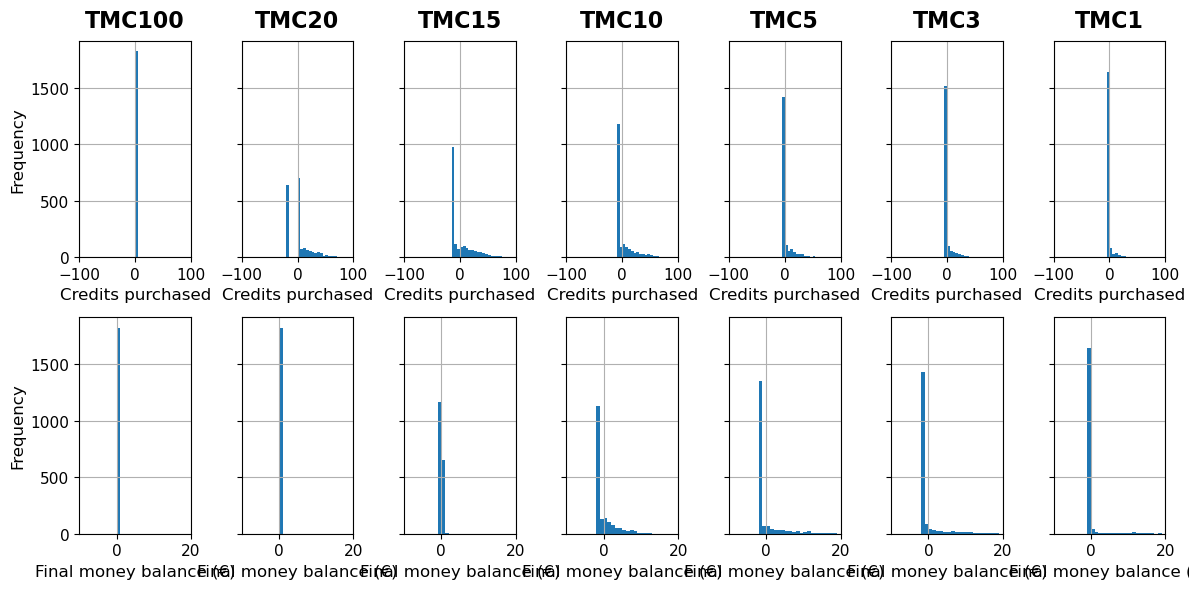

In [45]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].net_purchase.hist(ax=axes[0,i],bins=range(-100, 100, 5))
        axes[0, i].set_xlim(-100,100)
        axes[0, i].set_xlabel('Credits purchased', fontsize=12)

        (travs_df[scheme].net_purchase * evo_df[scheme]['price'].iloc[-1]).hist(ax=axes[1,i], bins=range(-10, 20, 1))
        axes[1, i].set_xlabel('Final money balance (€)', fontsize=12)
        axes[1, i].set_xlim(-10,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)

fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'balance-distr.png'), facecolor='w')

In [ ]:
evo_df[scheme]['price'].iloc[-1]

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1818    0.0
1819    0.0
1820    0.0
1821    0.0
1822    0.0
Name: money_balance, Length: 1823, dtype: float64

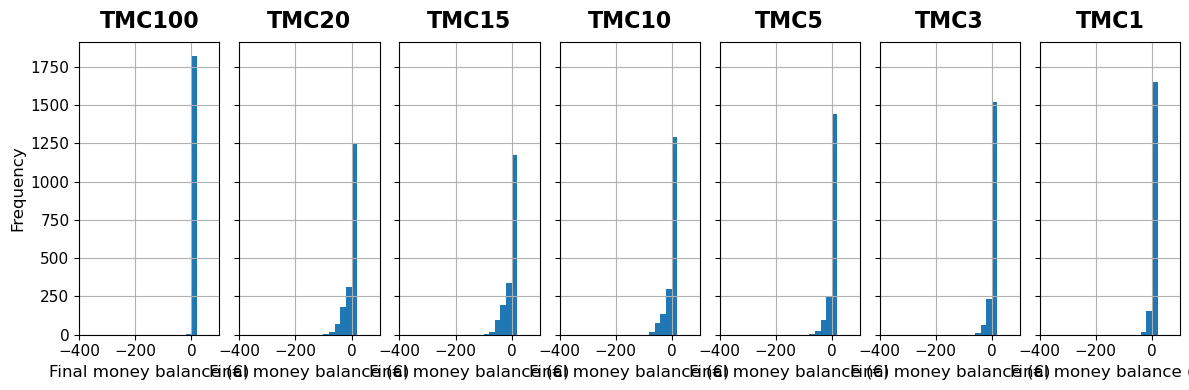

In [47]:
fig, axes = plt.subplots(nrows=1, ncols=n_tmc_scenarios, figsize=(12, 4), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        (-1*travs_df[scheme].net_purchase).hist(ax=axes[i], bins=range(-400, 100, 20))
        axes[i].set_xlabel('Final money balance (€)', fontsize=12)
        axes[i].set_xlim(-400,100)

        # Subtitle for scheme
        axes[i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
axes[0].set_ylabel('Frequency', fontsize=12)
# axes[1, 0].set_ylabel('Frequency', fontsize=12)

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)

fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'money-balance-distr.png'), facecolor='w')

C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_10708\2857498126.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


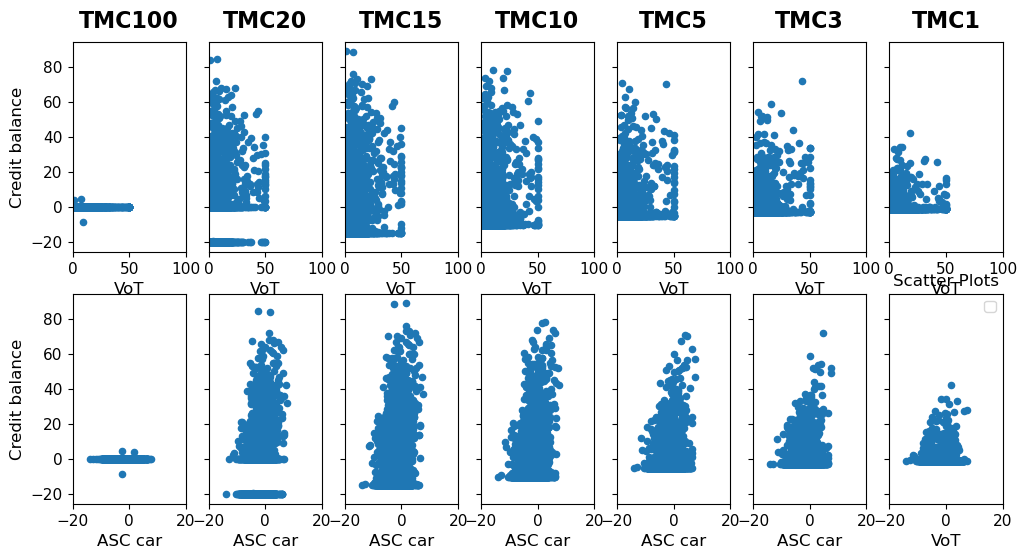

In [52]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].plot.scatter(x='VoT',y='net_purchase', ax=axes[0,i])
        axes[0, i].set_xlim(0,100)
        axes[0, i].set_xlabel('VoT', fontsize=12)

        travs_df[scheme].plot.scatter(x='ASC_car',y='net_purchase', ax=axes[1,i])
        axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
axes[0, 0].set_ylabel('Credit balance', fontsize=12)
axes[1, 0].set_ylabel('Credit balance', fontsize=12)

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)


# Get the columns starting with 'ASC'
asc_columns = [col for col in df.columns if col.startswith('ASC')]

# Create scatter plots
for column in asc_columns:
    plt.scatter(df['VoT'], df[column], label=column)

# Set labels and title
plt.xlabel('VoT')
plt.ylabel('net_purchase')
plt.title('Scatter Plots')
plt.legend()

# Show the plot
plt.show()

In [ ]:
# fig, axes = plt.subplots(nrows=1, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row', sharex=True)
# i = 0
# for scheme in dem_mgmt_schemes:
#     if scheme.startswith("tmc"):
#         travs_df[scheme].money_balance.hist(ax=axes[i])
#         i+=1
# # travs_df.money_balance.hist(bins=20)

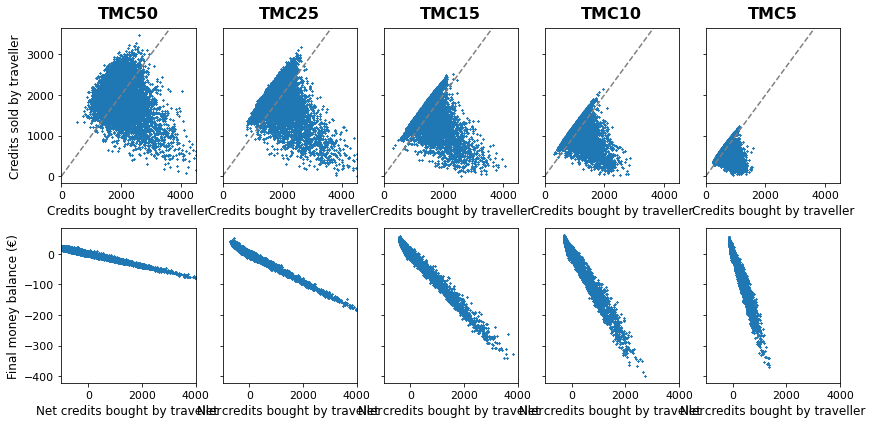

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].plot.scatter(x='tot_credit_bought', y='tot_credit_sold', marker='x', s=2, ax=axes[0, i])
        travs_df[scheme]['net_bought'] = travs_df[scheme].tot_credit_bought - travs_df[scheme].tot_credit_sold
        axes[0, i].axline((0, 0), slope=1, linestyle='--', color='grey')
        axes[0, i].set_xlabel('Credits bought by traveller', fontsize=12)
        axes[0, i].set_ylabel('Credits sold by traveller', fontsize=12)
        axes[0, i].set_xlim(0,4500)
        
        travs_df[scheme].plot.scatter(x='net_bought', y='money_balance', marker='x', s=2, ax=axes[1, i])
        axes[1, i].set_xlabel('Net credits bought by traveller', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=12)
        axes[1, i].set_xlim(-1000,4000)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.tight_layout()
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'buy-sell-stat.png'), facecolor='w')

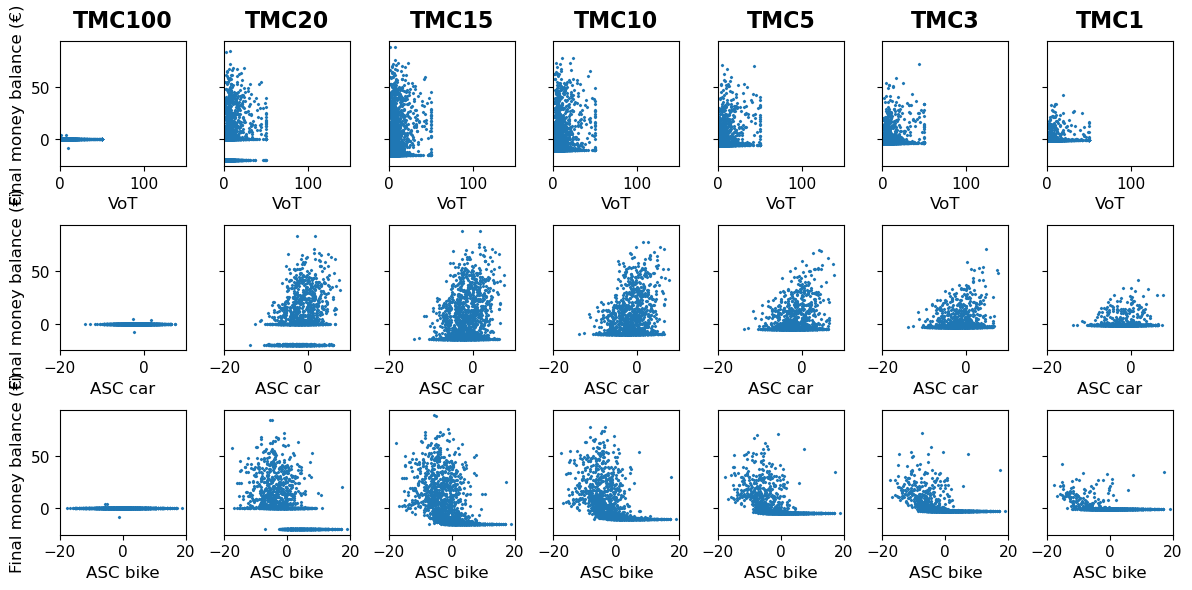

In [53]:
fig, axes = plt.subplots(nrows=3, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].plot.scatter(x='VoT', y='net_purchase', marker='x', s=2, ax=axes[0, i])
        axes[0, i].set_xlabel('VoT', fontsize=12)
        axes[0, i].set_ylabel('Final money balance (€)', fontsize=12)
        axes[0, i].set_xlim(0,150)
        
        travs_df[scheme].plot.scatter(x='ASC_car', y='net_purchase', marker='x', s=2, ax=axes[1, i])
        axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=12)
        axes[1, i].set_xlim(-20,10)

        travs_df[scheme].plot.scatter(x='ASC_bike', y='net_purchase', marker='x', s=2, ax=axes[2, i])
        axes[2, i].set_xlabel('ASC bike', fontsize=12)
        axes[2, i].set_ylabel("Final money balance (€)", fontsize=12)
        axes[2, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.tight_layout()
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'distr_effects.png'), facecolor='w')

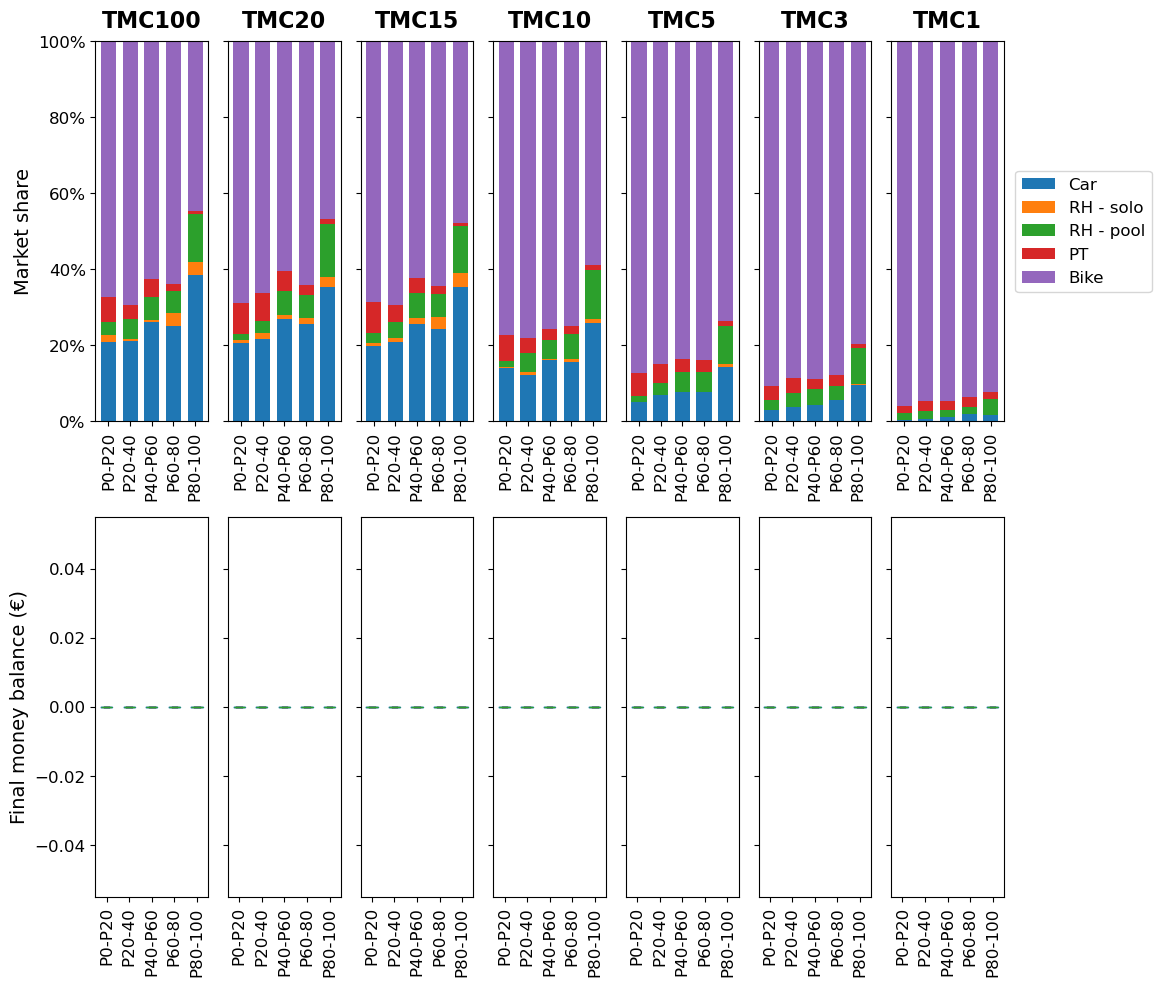

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 10), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        df = travs_df[scheme].copy()
        df['VoT_group'] = pd.qcut(travs_df[scheme]['VoT'], q=5, labels=['P0-P20', 'P20-40', 'P40-P60', 'P60-80', 'P80-100'])

        vot_groups = df['VoT_group'].unique()
        chosen_modes = ['car', 'bike', 'pt', 'rs_0', 'rs_1']  # include rs_0 explicitly

        # Create full MultiIndex
        full_index = pd.MultiIndex.from_product(
        [vot_groups, chosen_modes],
        names=['VoT_group', 'chosen_mode']
        )

        # Group and normalize to percentages
        counts = df.groupby(['VoT_group', 'chosen_mode'], observed=False).size()
        counts = counts.reindex(full_index, fill_value=0)

        # Convert to % of group (assuming equal group size)
        pivot_table = (counts.unstack() / (len(df) / len(vot_groups))) * 100

        # Plot
        pivot_table[['car','rs_0','rs_1','pt','bike']].plot(
        kind='bar',
        stacked=True,
        ax=axes[0, i],
        width=0.7
        )
        axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())
        axes[0, i].set_ylim(0,100)
        axes[0, i].set_xlabel('')
        axes[0, i].tick_params(axis='y', which='major', labelsize=20)
        # mean_money_per_group = df.groupby('VoT_group')['money_balance'].mean()
        # mean_money_per_group.plot(kind='bar', stacked=True, ax=axes[1, i])

        df.boxplot(column='money_balance', by='VoT_group', grid=False, ax=axes[1, i], whis=[0,100])

        if i == n_tmc_scenarios-1:
            axes[0, i].legend(labels=mode_labels, bbox_to_anchor=(1.1, 0.5), loc="center left", borderaxespad=0, fontsize=12)
        else:
            axes[0, i].get_legend().remove()
        axes[1, i].set_title('')
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=90)  # Change '45' to your desired rotation angle
        axes[1, i].set_xlabel('')

        if False:
            df['ASC_car_group'] = pd.qcut(travs_df[scheme]['ASC_car'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
            pivot_table_asc_car = df.groupby(['ASC_car_group', 'chosen_mode']).size().unstack(fill_value=0)
            pivot_table_asc_car.plot(kind='bar', stacked=True, ax=axes[2, i])
            df.boxplot(column='money_balance', by='ASC_car_group', grid=False, ax=axes[3, i])

        
        # travs_df[scheme].plot.scatter(x='VoT', y='money_balance', marker='x', s=2, ax=axes[0, i])
        # axes[0, i].set_xlabel('VoT', fontsize=12)
        axes[0, i].set_ylabel('Market share', fontsize=14)
        # axes[0, i].set_xlim(0,150)
        
        # travs_df[scheme].plot.scatter(x='ASC_car', y='money_balance', marker='x', s=2, ax=axes[1, i])
        # axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=14)
        # axes[1, i].set_xlim(-20,10)

        # travs_df[scheme].plot.scatter(x='ASC_bike', y='money_balance', marker='x', s=2, ax=axes[2, i])
        # axes[2, i].set_xlabel('ASC bike', fontsize=12)
        # axes[2, i].set_ylabel("Final money balance (€)", fontsize=12)
        # axes[2, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.suptitle('')
fig.tight_layout(h_pad=2)
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'market-share-vot.png'), facecolor='w')

chosen_mode,bike,car,pt,rs_0,rs_1
VoT_group,,,,,
P0-P20,87.493143,5.211190,6.034010,0.00000,1.371366
P20-40,84.750411,6.856829,4.936917,0.00000,3.291278
P40-P60,83.653319,7.679649,3.565551,0.00000,5.211190
P60-80,83.653319,7.679649,3.291278,0.00000,5.211190
P80-100,73.779484,14.262205,1.097093,0.82282,10.148108


C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_10708\4018446264.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(monetary_vot['tmc10'].groupby('VoT_group')['money_balance'].mean())


VoT_group
P0-P20    -0.420393
P20-40    -0.321548
P40-P60   -0.016786
P60-80    -0.094210
P80-100    0.851797
Name: money_balance, dtype: float64

C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_10708\4018446264.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(monetary_vot['tmc5'].groupby('VoT_group')['money_balance'].mean())


VoT_group
P0-P20    -0.685999
P20-40    -0.442875
P40-P60   -0.196243
P60-80    -0.115061
P80-100    1.438649
Name: money_balance, dtype: float64

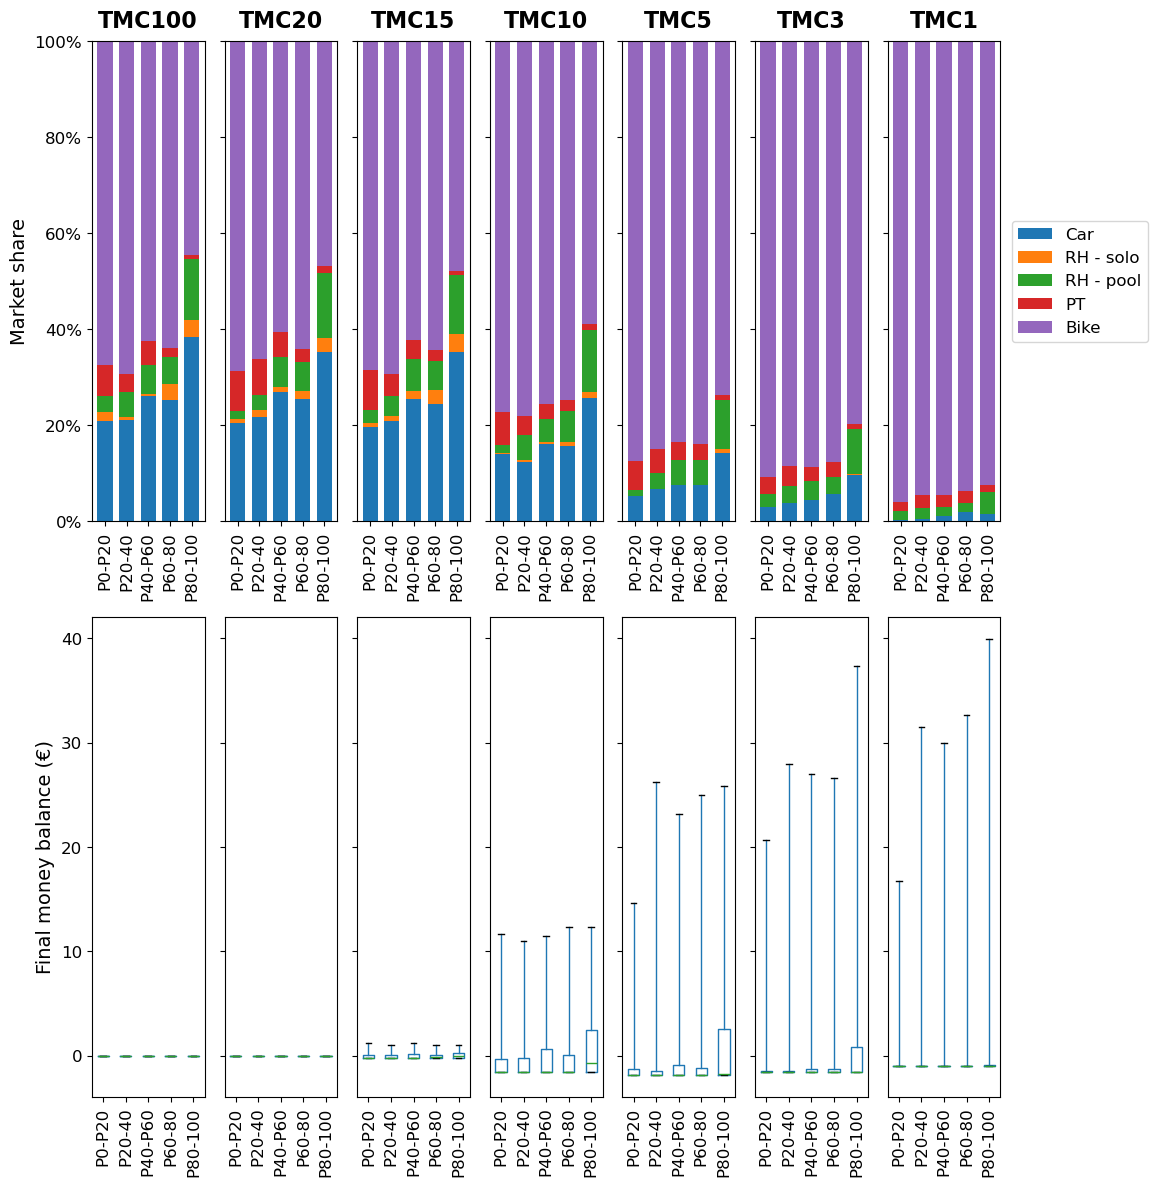

In [68]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 12), sharey='row')
ms_vot = dict()
monetary_vot = dict()
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        df = travs_df[scheme].copy()
        df['VoT_group'] = pd.qcut(travs_df[scheme]['VoT'], q=5, labels=['P0-P20', 'P20-40', 'P40-P60', 'P60-80', 'P80-100'])

        vot_groups = df['VoT_group'].unique()
        chosen_modes = ['car', 'bike', 'pt', 'rs_0', 'rs_1']  # include rs_0 explicitly

        # Create full MultiIndex
        full_index = pd.MultiIndex.from_product(
        [vot_groups, chosen_modes],
        names=['VoT_group', 'chosen_mode']
        )

        # Group and normalize to percentages
        ms_vot[scheme] = df.groupby(['VoT_group', 'chosen_mode'], observed=False).size()
        ms_vot[scheme] = ms_vot[scheme].reindex(full_index, fill_value=0).unstack(fill_value=0) / (len(df) / 5) * 100

        # # Convert to % of group (assuming equal group size)
        # pivot_table = (counts.unstack() / (len(df) / len(vot_groups))) * 100

        # ms_vot[scheme] = df.groupby(['VoT_group', 'chosen_mode']).size().unstack(fill_value=0) / (len(df) / 5) * 100
        ms_vot[scheme][['car','rs_0','rs_1', 'pt', 'bike']].plot(kind='bar', stacked=True, ax=axes[0, i], width=0.7)
        axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())
        axes[0, i].set_ylim(0,100)
        axes[0, i].set_xlabel('')
        axes[0, i].tick_params(axis='y', which='major', labelsize=20)
        # mean_money_per_group = df.groupby('VoT_group')['money_balance'].mean()
        # mean_money_per_group.plot(kind='bar', stacked=True, ax=axes[1, i])

        df['money_balance'] = df['net_purchase'] * evo_df[scheme]['price'].iloc[-1]
        df.boxplot(column='money_balance', by='VoT_group', grid=False, ax=axes[1, i], whis=[0,100])
        monetary_vot[scheme] = df.copy()

        if i == n_tmc_scenarios-1:
            axes[0, i].legend(labels=mode_labels, bbox_to_anchor=(1.1, 0.5), loc="center left", borderaxespad=0, fontsize=12)
        else:
            axes[0, i].get_legend().remove()
        axes[1, i].set_title('')
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=90)  # Change '45' to your desired rotation angle
        axes[1, i].set_xlabel('')

        if False:
            df['ASC_car_group'] = pd.qcut(travs_df[scheme]['ASC_car'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
            pivot_table_asc_car = df.groupby(['ASC_car_group', 'chosen_mode']).size().unstack(fill_value=0)
            pivot_table_asc_car.plot(kind='bar', stacked=True, ax=axes[2, i])
            df.boxplot(column='money_balance', by='ASC_car_group', grid=False, ax=axes[3, i])

        
        # travs_df[scheme].plot.scatter(x='VoT', y='money_balance', marker='x', s=2, ax=axes[0, i])
        # axes[0, i].set_xlabel('VoT', fontsize=12)
        axes[0, i].set_ylabel('Market share', fontsize=14)
        # axes[0, i].set_xlim(0,150)
        
        # travs_df[scheme].plot.scatter(x='ASC_car', y='money_balance', marker='x', s=2, ax=axes[1, i])
        # axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=14)
        # axes[1, i].set_xlim(-20,10)

        # travs_df[scheme].plot.scatter(x='ASC_bike', y='money_balance', marker='x', s=2, ax=axes[2, i])
        # axes[2, i].set_xlabel('ASC bike', fontsize=12)
        # axes[2, i].set_ylabel("Final money balance (€)", fontsize=12)
        # axes[2, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC").replace("_lic", "-LIC").replace("_p", "-P")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.suptitle('')
fig.tight_layout(h_pad=2)
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'market-share-vot.png'), facecolor='w')
display(ms_vot['tmc5'])
display(monetary_vot['tmc10'].groupby('VoT_group')['money_balance'].mean())
display(monetary_vot['tmc5'].groupby('VoT_group')['money_balance'].mean())

In [69]:
def determine_preferred_mode(travs_df):
    '''determine preferred mode based on ASCs alone'''
    df = travs_df.copy()
    df['preferred_mode'] = df[['ASC_car', 'ASC_rs', 'ASC_pt', 'ASC_bike']].idxmax(axis=1)
    df['preferred_mode'] = df['preferred_mode'].apply(lambda x: x.split('_')[1])
    return df['preferred_mode']

for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme]['pref_mode'] = determine_preferred_mode(travs_df[scheme])
travs_df['tmc10']['pref_mode']

0       bike
1       bike
2       bike
3        car
4        car
        ... 
1818    bike
1819      pt
1820    bike
1821     car
1822      rs
Name: pref_mode, Length: 1823, dtype: object

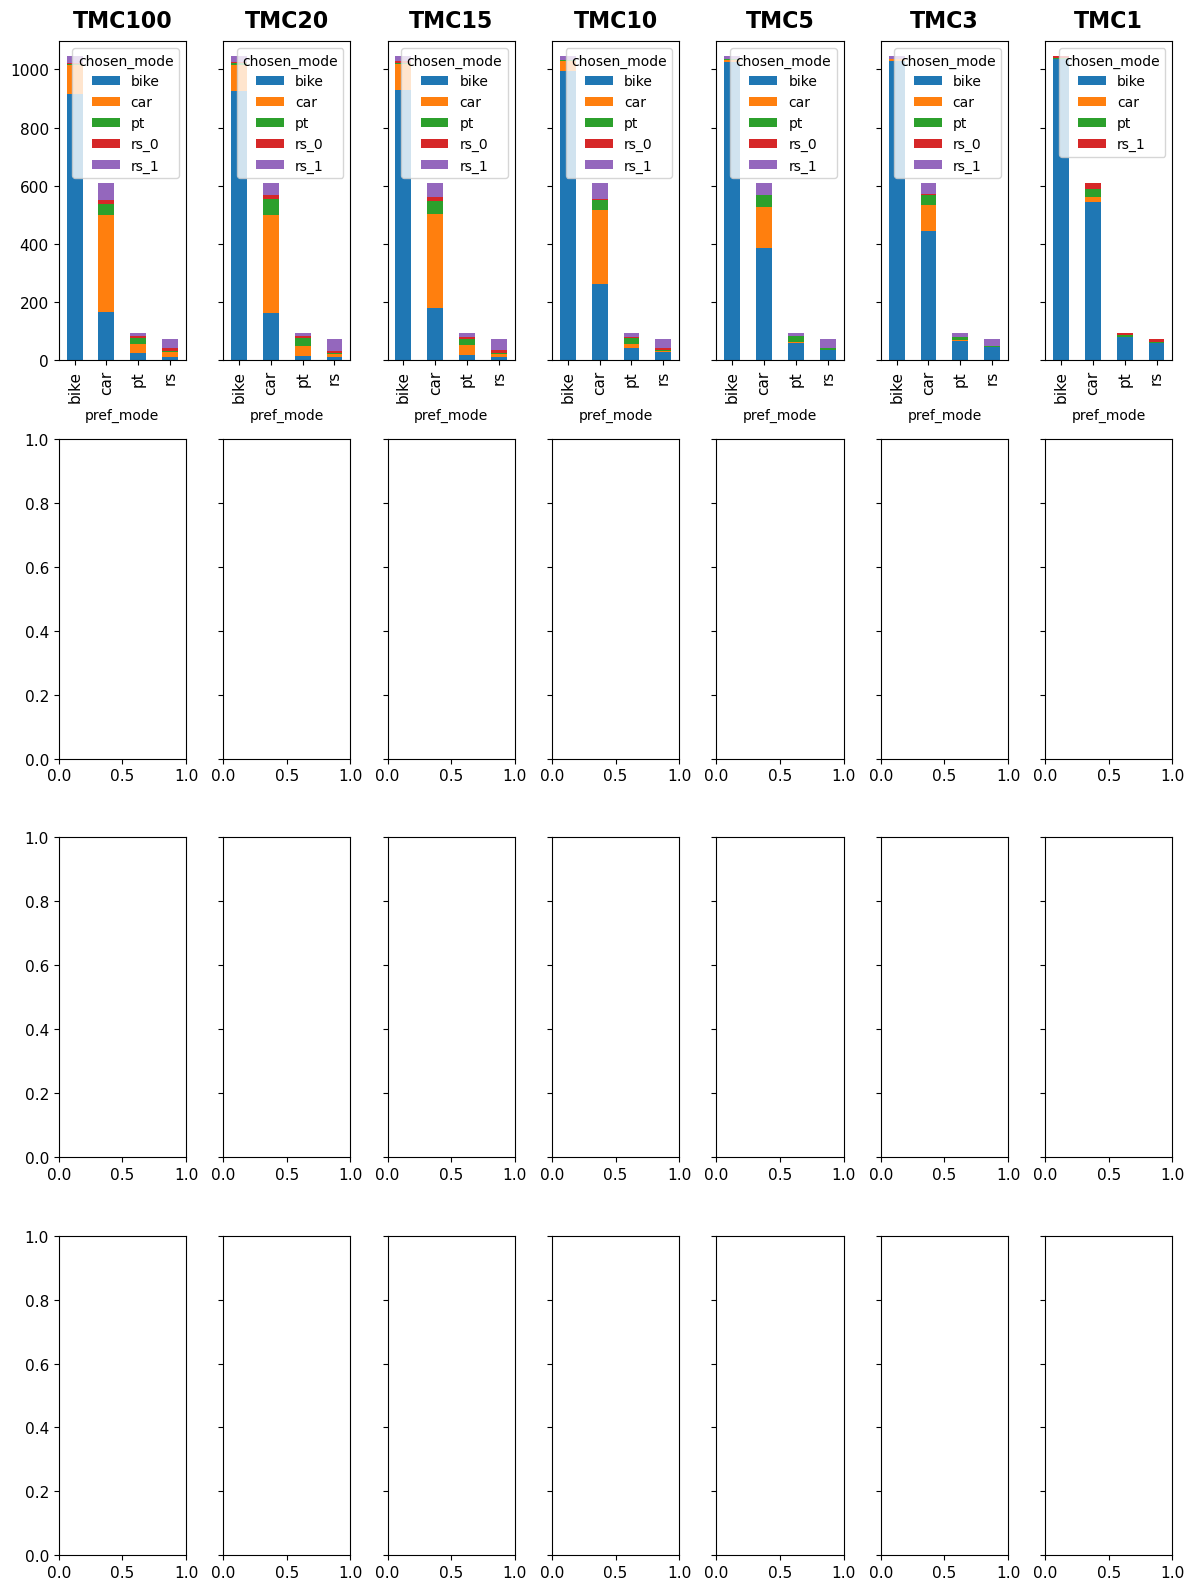

In [70]:
fig, axes = plt.subplots(nrows=4, ncols=n_tmc_scenarios, figsize=(12, 16), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        df = travs_df[scheme].copy()
        # df['pref_mode_group'] = pd.qcut(travs_df[scheme]['preferred_mode'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        pivot_table = df.groupby(['pref_mode', 'chosen_mode']).size().unstack(fill_value=0)
        pivot_table.plot(kind='bar', stacked=True, ax=axes[0, i])
        
        # mean_money_per_group = df.groupby('VoT_group')['money_balance'].mean()
        # mean_money_per_group.plot(kind='bar', stacked=True, ax=axes[1, i])

        # df.boxplot(column='money_balance', by='VoT_group', grid=False, ax=axes[1, i])

        # df['ASC_car_group'] = pd.qcut(travs_df[scheme]['ASC_car'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        # pivot_table_asc_car = df.groupby(['ASC_car_group', 'chosen_mode']).size().unstack(fill_value=0)
        # pivot_table_asc_car.plot(kind='bar', stacked=True, ax=axes[2, i])

        # df.boxplot(column='money_balance', by='ASC_car_group', grid=False, ax=axes[3, i])

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.tight_layout()
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'market-share-ASC.png'), facecolor='w')

In [71]:
travs_df['tmc10'].keys()
# travs_df.keys()

Index(['pax', 'chosen_mode', 'time_occ_1', 'time_occ_2', 'time_occ_3',
       'informed', 'days_since_reg', 'tmc_balance', 'net_purchase',
       'denied_order', 'money_balance', 'tot_credit_bought', 'tot_credit_sold',
       'requests_0', 'requests_1', 'gets_offer_0', 'gets_offer_1',
       'accepts_offer_0', 'accepts_offer_1', 'xp_wait_0', 'xp_wait_1',
       'corr_xp_wait_0', 'corr_xp_wait_1', 'xp_ivt_0', 'xp_ivt_1',
       'xp_km_fare_0', 'xp_km_fare_1', 'registered_0', 'registered_1',
       'expected_wait_0', 'expected_wait_1', 'expected_ivt_0',
       'expected_ivt_1', 'expected_km_fare_0', 'expected_km_fare_1',
       'Unnamed: 0', 'pax_id', 'origin', 'destination', 'treq', 'dist',
       'ttrav_car', 'ttrav_bike', 'PT_ivTime', 'PT_waitingTime', 'PTfare',
       'through_center', 'VoT', 'ASC_rs', 'ASC_pool', 'ASC_car', 'ASC_pt',
       'ASC_bike', 'multihoming', 'bike_option', 'car_option', 'pref_mode'],
      dtype='object')

In [72]:
travs_df['tmc10'].ttrav

AttributeError: 'DataFrame' object has no attribute 'ttrav'

In [73]:
cgp_costs = dict()
for scheme in dem_mgmt_schemes:
    if scheme.startswith("cgp"):
        cgp_costs[scheme] = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'day_{}_travs.csv'.format(params[scheme]['nD']-1)))['paid_cgp']
        for day_left in range(2, n_days_eql+1):
            day_df = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'day_{}_travs.csv'.format(params[scheme]['nD'] - day_left)))
            cgp_costs[scheme] += day_df['paid_cgp']
        cgp_costs[scheme] = cgp_costs[scheme] / n_days_eql

In [74]:
def count_startswith(lst, prefix):
    return sum(1 for item in lst if item.startswith(prefix))

n_cgp_scenarios = count_startswith(dem_mgmt_schemes, "cgp")

if n_cgp_scenarios > 1:
    fig, axes = plt.subplots(nrows=1, ncols=n_cgp_scenarios, figsize=(12, 4), sharey='row')
    i = 0
    for scheme in dem_mgmt_schemes:
        if scheme.startswith("cgp"):
            cgp_costs[scheme].hist(ax=axes[i], bins=np.arange(0, 10, 1))
            axes[i].set_xlabel('Final money balance (€)', fontsize=12)
            # axes[i].set_xlim(-400,100)

            # Subtitle for scheme
            axes[i].set_title('{}'.format(scheme.replace("cgp", "CGP")), fontweight='bold', pad=10, fontsize=16)

            i+=1
    axes[0].set_ylabel('Frequency', fontsize=12)
    # axes[1, 0].set_ylabel('Frequency', fontsize=12)

    for a in axes.flatten():
        a.tick_params(axis='both', which='major', labelsize=11)

else:
    
    for scheme in dem_mgmt_schemes:
        if scheme.startswith("cgp"):
            cgp_costs[scheme].hist(bins=np.arange(0, 10, 0.25))
            ax.set_xlabel('Final money balance (€)', fontsize=12)
            # ax.set_xlim(-400,100)

            # Subtitle for scheme
            ax.set_title('{}'.format(scheme.replace("cgp", "CGP")), fontweight='bold', pad=10, fontsize=16)
            i+=1
    ax.set_ylabel('Frequency', fontsize=12)
    plt.show()

fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'cgp-paid-distr.png'), facecolor='w')

<Figure size 640x480 with 0 Axes>

In [79]:
travs_df['tmc10'].columns

Index(['pax', 'chosen_mode', 'time_occ_1', 'time_occ_2', 'time_occ_3',
       'informed', 'days_since_reg', 'tmc_balance', 'net_purchase',
       'denied_order', 'money_balance', 'tot_credit_bought', 'tot_credit_sold',
       'requests_0', 'requests_1', 'gets_offer_0', 'gets_offer_1',
       'accepts_offer_0', 'accepts_offer_1', 'xp_wait_0', 'xp_wait_1',
       'corr_xp_wait_0', 'corr_xp_wait_1', 'xp_ivt_0', 'xp_ivt_1',
       'xp_km_fare_0', 'xp_km_fare_1', 'registered_0', 'registered_1',
       'expected_wait_0', 'expected_wait_1', 'expected_ivt_0',
       'expected_ivt_1', 'expected_km_fare_0', 'expected_km_fare_1',
       'Unnamed: 0', 'pax_id', 'origin', 'destination', 'treq', 'dist',
       'ttrav_car', 'ttrav_bike', 'PT_ivTime', 'PT_waitingTime', 'PTfare',
       'through_center', 'VoT', 'ASC_rs', 'ASC_pool', 'ASC_car', 'ASC_pt',
       'ASC_bike', 'multihoming', 'bike_option', 'car_option', 'pref_mode'],
      dtype='object')